
===== CELL A — ROOT PORTABLE EXTRACTION + NP↔NI ALIGNMENT =====
User inputs loaded.
Analysis folder: G:\Kevin\2026-03-17_14-26-00\Record Node 114\2026-03-17_14-26-00_experiment1_recording1_analysis

NI continuous (absolute): 15.569667 → 1077.636300 s
NP continuous (absolute): 15.555373 → 1077.622525 s

Canonical t0 = NP stream start = 15.555373 s (absolute)
NI stream starts +0.014294 s relative to t0

===== NP ↔ NI SYNC ALIGNMENT =====
NI sync pulses (bit 3): 1062
NP sync pulses (bit 0): 1062

Linear fit: t_NI = 1.000000009 * t_NP + -0.000001405
Residuals  mean=0.0000 ms  std=0.0327 ms  max=0.1348 ms

Saved alignment metadata.

Recording duration (canonical): 1062.067 s

===== SPIKE TIME ANCHOR DIAGNOSTIC =====
NI stream offset from NP start: +0.014294 s
First 5 spike times (raw, seconds from sample 0): [3.33333333e-05 6.66666667e-05 6.66666667e-05 1.00000000e-04
 1.33333333e-04]
Last  5 spike times (raw, seconds from sample 0): [1061.9585     1061.9595     1061.99856667 1061.99926667

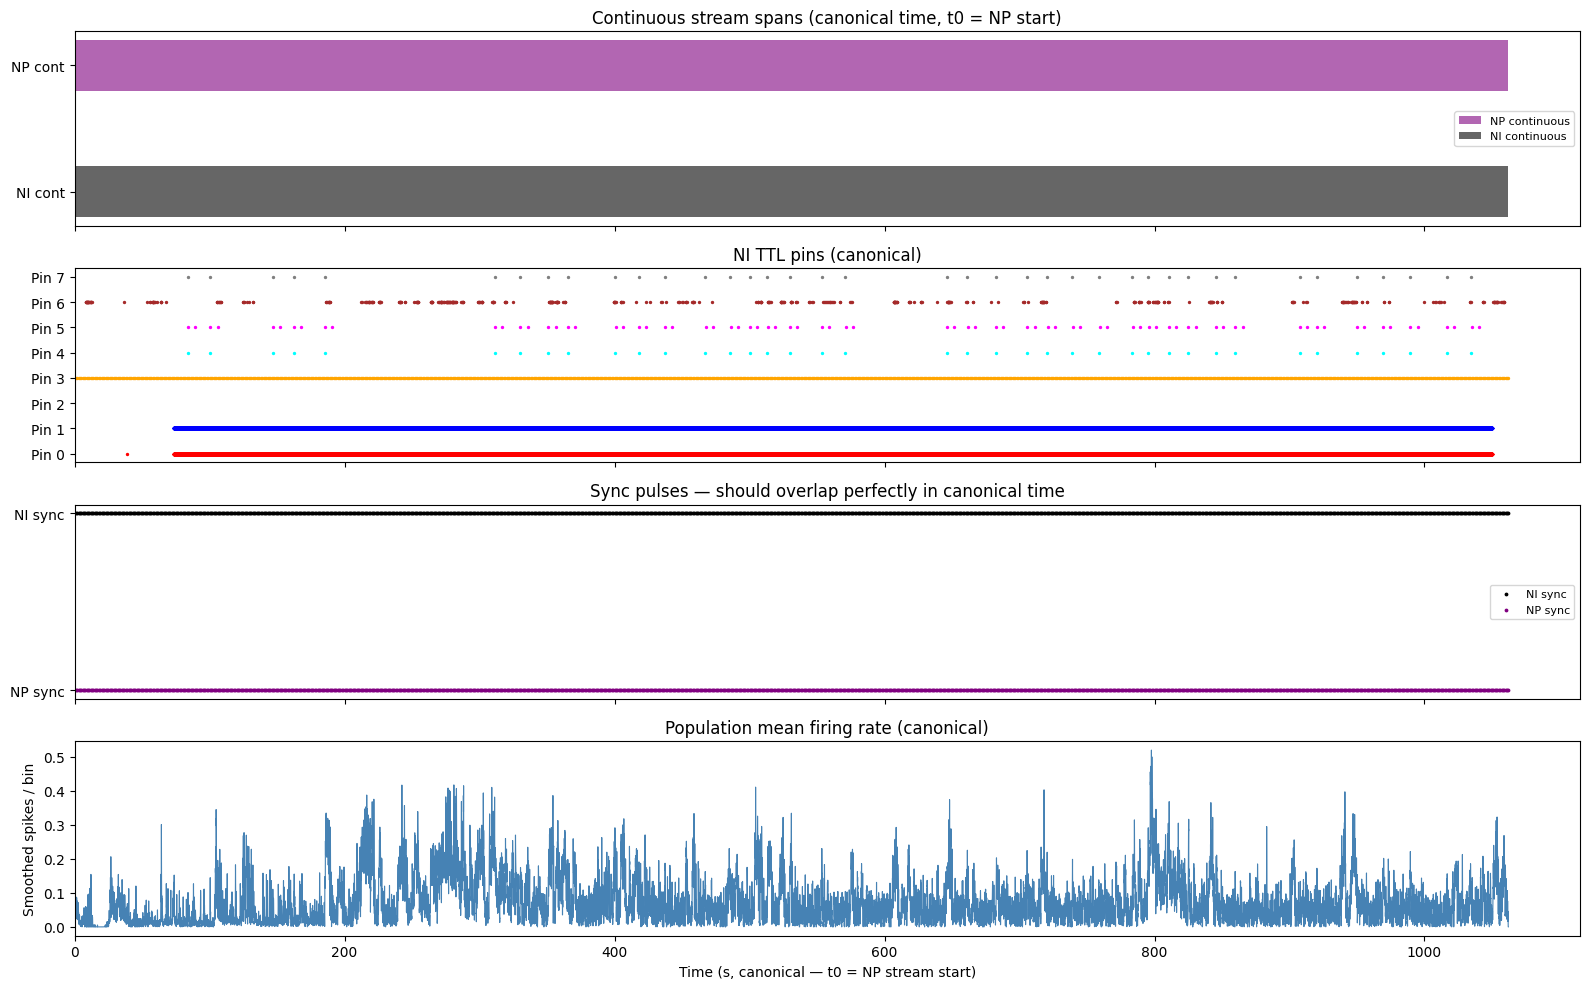

===== CELL A COMPLETE =====



In [1]:
# ============================================================
# =======================  CELL A  ============================
# ========== ROOT CELL — TTLs + QC + PORTABLE SPIKES =========
# ========== WITH NP ↔ NI CLOCK ALIGNMENT (SYNC) =============
# ============================================================

import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL A — ROOT PORTABLE EXTRACTION + NP↔NI ALIGNMENT =====")

# ------------------------------------------------------------
# USER INPUTS
# ------------------------------------------------------------

SESSION_FOLDER = r"D:\Kevin\17032026"

NI_TTL_FOLDER = r"G:\Kevin\2026-03-17_14-26-00\Record Node 114\experiment1\recording1\events\NI-DAQmx-106.PXIe-6341\TTL"
PROBEA_PATH   = r"G:\Kevin\2026-03-17_14-26-00\Record Node 114\experiment1\recording1\continuous\Neuropix-PXI-107.ProbeA\kilosort4"

EXPERIMENT_NUMBER = 1

CAMERA_TTL_PIN = 0
EXPECTED_RATE_HZ = 60
MISSING_TTL_THRESHOLD = 60
MIN_BLOCK_LENGTH = 500

FILENAME_PATTERN = r"frame_(\d+)_cnt_(\d+)\.raw"

NI_SYNC_BIT = 3
NP_SYNC_BIT = 0

NP_SAMPLE_RATE = 30000.0

print("User inputs loaded.")

# ------------------------------------------------------------
# UNIFIED ANALYSIS FOLDER
# ------------------------------------------------------------

def find_session_root(path):
    path = Path(path).resolve()
    while True:
        if "record node" in path.name.lower():
            return path
        parent = path.parent
        if parent == path:
            raise RuntimeError("Could not find 'Record Node' folder above given path")
        path = parent

def build_analysis_folder(session_root, experiment_number):
    experiment_folders = sorted(
        [f for f in session_root.iterdir()
         if f.is_dir() and f.name.lower().startswith("experiment")],
        key=lambda p: p.name
    )
    if experiment_number < 1 or experiment_number > len(experiment_folders):
        raise RuntimeError(f"Experiment {experiment_number} not found.")
    experiment_folder = experiment_folders[experiment_number - 1]
    recording_folders = sorted(
        [f for f in experiment_folder.iterdir()
         if f.is_dir() and f.name.lower().startswith("recording")],
        key=lambda p: p.name
    )
    if not recording_folders:
        raise RuntimeError("No recording folder found.")
    recording_folder = recording_folders[0]
    session_date = session_root.parent.name
    folder_name = f"{session_date}_{experiment_folder.name}_{recording_folder.name}_analysis"
    analysis_folder = session_root / folder_name
    analysis_folder.mkdir(exist_ok=True)
    for sf in ["qc","camera_alignment","dlc_alignment","behavior_ttls",
               "peak_detection","metadata","ttls","spikes"]:
        (analysis_folder / sf).mkdir(exist_ok=True)
    print(f"Analysis folder: {analysis_folder}")
    return analysis_folder

analysis_folder = build_analysis_folder(
    find_session_root(PROBEA_PATH), EXPERIMENT_NUMBER
)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def save_incrementing(folder, base_name, array):
    folder = Path(folder)
    folder.mkdir(exist_ok=True)
    path = folder / f"{base_name}.npy"
    if not path.exists():
        np.save(path, array)
        return path
    counter = 1
    while True:
        path = folder / f"{base_name}_{counter}.npy"
        if not path.exists():
            np.save(path, array)
            return path
        counter += 1

def extract_rising_edges(full_words, timestamps, pin):
    mask = 1 << pin
    bit_on = (full_words & mask) > 0
    bit_prev = np.roll(bit_on, 1)
    bit_prev[0] = False
    rising = (~bit_prev) & bit_on
    return timestamps[rising]

# ------------------------------------------------------------
# LOAD CONTINUOUS TIMESTAMPS
# ------------------------------------------------------------

ni_ttl_folder    = Path(NI_TTL_FOLDER)
ni_device_name   = ni_ttl_folder.parent.name            # NI-DAQmx-106.PXIe-6341
recording_root   = ni_ttl_folder.parents[2]             # .../experiment2/recording1
ni_cont_folder   = recording_root / "continuous" / ni_device_name
probe_cont_folder = Path(PROBEA_PATH).parent            # .../Neuropix-PXI-107.ProbeA

ni_cont_timestamps = np.load(ni_cont_folder   / "timestamps.npy")
np_cont_timestamps = np.load(probe_cont_folder / "timestamps.npy")

ni_start_abs = float(ni_cont_timestamps[0])
ni_end_abs   = float(ni_cont_timestamps[-1])
np_start_abs = float(np_cont_timestamps[0])
np_end_abs   = float(np_cont_timestamps[-1])

print(f"\nNI continuous (absolute): {ni_start_abs:.6f} → {ni_end_abs:.6f} s")
print(f"NP continuous (absolute): {np_start_abs:.6f} → {np_end_abs:.6f} s")

# ============================================================
# CANONICAL TIMEBASE DECISION
# ============================================================
# We use the NP continuous start as t0 (our ground truth).
# Everything — spikes, TTLs, DLC — will be expressed as seconds
# elapsed since the NP recording began.
#
# Why NP and not NI?
#   - Kilosort spike_times.npy is in NP samples from NP stream start.
#   - The NP stream is always the longest / most complete signal.
#   - All other signals get mapped into this frame.
# ============================================================

t0 = np_start_abs   # canonical zero = NP stream start (absolute clock)

print(f"\nCanonical t0 = NP stream start = {t0:.6f} s (absolute)")
print(f"NI stream starts {ni_start_abs - t0:+.6f} s relative to t0")
# Positive → NI started after NP (common if NP armed first)

# ------------------------------------------------------------
# SYNC PULSE ALIGNMENT: verify NP↔NI are on same clock
# ------------------------------------------------------------

print("\n===== NP ↔ NI SYNC ALIGNMENT =====")

timestamps_ni_ttl = np.load(ni_ttl_folder / "timestamps.npy")
full_words_ni     = np.load(ni_ttl_folder / "full_words.npy")

np_ttl_folder     = recording_root / "events" / "Neuropix-PXI-107.ProbeA" / "TTL"
timestamps_np_ttl = np.load(np_ttl_folder / "timestamps.npy")
full_words_np     = np.load(np_ttl_folder / "full_words.npy")

sync_times_ni_abs = extract_rising_edges(full_words_ni, timestamps_ni_ttl, NI_SYNC_BIT)
sync_times_np_abs = extract_rising_edges(full_words_np, timestamps_np_ttl, NP_SYNC_BIT)

print(f"NI sync pulses (bit {NI_SYNC_BIT}): {len(sync_times_ni_abs)}")
print(f"NP sync pulses (bit {NP_SYNC_BIT}): {len(sync_times_np_abs)}")

if len(sync_times_ni_abs) == 0:
    raise RuntimeError("No NI sync pulses found.")
if len(sync_times_np_abs) == 0:
    raise RuntimeError("No NP sync pulses found.")

n_common = min(len(sync_times_np_abs), len(sync_times_ni_abs))
sync_np  = sync_times_np_abs[:n_common]
sync_ni  = sync_times_ni_abs[:n_common]

A_mat = np.vstack([sync_np, np.ones_like(sync_np)]).T
a_fit, b_fit = np.linalg.lstsq(A_mat, sync_ni, rcond=None)[0]
residuals = sync_ni - (a_fit * sync_np + b_fit)

print(f"\nLinear fit: t_NI = {a_fit:.9f} * t_NP + {b_fit:.9f}")
print(f"Residuals  mean={np.mean(residuals)*1000:.4f} ms  "
      f"std={np.std(residuals)*1000:.4f} ms  "
      f"max={np.max(np.abs(residuals))*1000:.4f} ms")

# With a≈1 and b≈0 (same clock), the fit confirms the two streams share
# the OpenEphys master clock.  We still apply it for correctness in case
# there is any tiny drift.

# Save alignment metadata
align_meta = {
    "np_to_ni_a": float(a_fit),
    "np_to_ni_b": float(b_fit),
    "n_pulses": int(n_common),
    "residual_mean_s": float(np.mean(residuals)),
    "residual_std_s":  float(np.std(residuals)),
    "residual_max_abs_s": float(np.max(np.abs(residuals))),
    "ni_sync_bit": int(NI_SYNC_BIT),
    "np_sync_bit": int(NP_SYNC_BIT),
    "t0_abs": float(t0),
    "ni_start_abs": float(ni_start_abs),
    "np_start_abs": float(np_start_abs),
    "ni_start_rel": float(ni_start_abs - t0),
    "ni_end_rel":   float(ni_end_abs   - t0),
    "np_start_rel": 0.0,
    "np_end_rel":   float(np_end_abs   - t0),
}
with open(analysis_folder / "metadata" / "np_ni_alignment.json", "w") as f:
    json.dump(align_meta, f, indent=2)
print(f"\nSaved alignment metadata.")

# ============================================================
# UNIFIED CONVERSION FUNCTIONS
# ============================================================
# All downstream code should use these — never subtract t0 manually.

def np_samples_to_canonical(samples):
    """Kilosort spike_times (NP samples) → canonical seconds."""
    # samples / sample_rate  → seconds from NP stream start (already = t0)
    # No further offset needed because t0 IS np_start_abs and
    # OpenEphys sample indices start at the stream start.
    return samples / NP_SAMPLE_RATE

def np_abs_to_canonical(t_np_abs):
    """NP absolute time → canonical seconds."""
    return t_np_abs - t0

def ni_abs_to_canonical(t_ni_abs):
    """NI absolute time → canonical seconds."""
    return t_ni_abs - t0

# Canonical duration = full NP recording
recording_duration = float(np_end_abs - t0)
print(f"\nRecording duration (canonical): {recording_duration:.3f} s")

# ============================================================
# CRITICAL DIAGNOSTIC: verify spike time anchor
# ============================================================
# Load spike_times.npy and check that the first and last spikes
# fall within [0, recording_duration].  If they fall within
# [-ni_start_rel, recording_duration - ni_start_rel] instead,
# that means Kilosort spike_times are in NI-absolute samples,
# and you need to subtract the NP stream start offset.
# ============================================================

spike_times_raw = np.load(Path(PROBEA_PATH) / "spike_times.npy").flatten()
spike_times_sec_raw = spike_times_raw / NP_SAMPLE_RATE

ni_start_rel = ni_start_abs - t0   # typically a small positive number

print(f"\n===== SPIKE TIME ANCHOR DIAGNOSTIC =====")
print(f"NI stream offset from NP start: {ni_start_rel:+.6f} s")
print(f"First 5 spike times (raw, seconds from sample 0): "
      f"{spike_times_sec_raw[:5]}")
print(f"Last  5 spike times (raw, seconds from sample 0): "
      f"{spike_times_sec_raw[-5:]}")
print(f"Expected canonical range: 0 → {recording_duration:.3f} s")
print(f"If spikes appear in range {-ni_start_rel:.3f} → "
      f"{recording_duration - ni_start_rel:.3f} s")
print(f"  → spike_times are anchored to NI start, not NP start.")
print(f"  → You need: spike_canonical = spikes_sec - {ni_start_rel:.6f}")
print(f"If spikes appear in range 0 → {recording_duration:.3f} s")
print(f"  → spike_times are anchored to NP start (correct, no adjustment).")

# Auto-detect anchor and apply correct conversion
spike_min = float(spike_times_sec_raw.min())
spike_max = float(spike_times_sec_raw.max())

if abs(spike_min) < 5.0 and spike_max <= recording_duration + 5.0:
    print("\n→ AUTO-DETECTED: spikes anchored to NP start. No offset needed.")
    spike_anchor_offset = 0.0
elif abs(spike_min - ni_start_rel) < 5.0:
    print(f"\n→ AUTO-DETECTED: spikes anchored to NI start. "
          f"Applying offset of -{ni_start_rel:.6f} s.")
    spike_anchor_offset = ni_start_rel
else:
    print(f"\n→ WARNING: spike anchor unclear. "
          f"spike_min={spike_min:.3f}, ni_start_rel={ni_start_rel:.6f}. "
          f"Defaulting to 0 offset — PLEASE VERIFY MANUALLY.")
    spike_anchor_offset = 0.0

print(f"spike_anchor_offset = {spike_anchor_offset:.6f} s")

def spikes_to_canonical(spike_samples):
    """Full pipeline: NP samples → canonical seconds."""
    return spike_samples / NP_SAMPLE_RATE - spike_anchor_offset

# ============================================================
# NI TTL EXTRACTION → canonical time
# ============================================================

print("\n===== EXTRACTING NI TTLs → CANONICAL TIME =====")

ttls_dir = analysis_folder / "ttls"
all_pin_ttls = {}   # canonical seconds

for pin in range(8):
    ttls_abs = extract_rising_edges(full_words_ni, timestamps_ni_ttl, pin)
    ttls_can = ni_abs_to_canonical(ttls_abs)
    all_pin_ttls[pin] = ttls_can
    save_incrementing(ttls_dir, f"TTL_Pin_{pin}", ttls_can)
    print(f"  Pin {pin}: {len(ttls_can)} TTLs", end="")
    if len(ttls_can):
        print(f"  range {ttls_can[0]:.3f} → {ttls_can[-1]:.3f} s")
    else:
        print()

ni_meta = {
    "canonical_t0_is": "NP stream start (np_start_abs)",
    "t0_abs": float(t0),
    "ni_start_canonical": float(ni_start_abs - t0),
    "ni_end_canonical":   float(ni_end_abs   - t0),
    "np_start_canonical": 0.0,
    "np_end_canonical":   float(np_end_abs   - t0),
    "recording_duration": float(recording_duration),
    "camera_ttl_pin": int(CAMERA_TTL_PIN),
    "expected_rate_hz": EXPECTED_RATE_HZ,
    "spike_anchor_offset_s": float(spike_anchor_offset),
}
with open(analysis_folder / "metadata" / "ttl_metadata.json", "w") as f:
    json.dump(ni_meta, f, indent=2)
print("Saved TTL metadata.")

# ============================================================
# TTL BLOCK DETECTION
# ============================================================

print("\n===== TTL BLOCK DETECTOR =====")

rising_times = all_pin_ttls[CAMERA_TTL_PIN]
print(f"Camera pin {CAMERA_TTL_PIN}: {len(rising_times)} rising edges")

ipi           = np.diff(rising_times)
expected_ipi  = 1.0 / EXPECTED_RATE_HZ
gap_threshold = expected_ipi * MISSING_TTL_THRESHOLD
gap_indices   = np.where(ipi > gap_threshold)[0]

block_starts = np.insert(gap_indices + 1, 0, 0)
block_ends   = np.append(gap_indices, len(rising_times) - 1)

ttl_blocks = []
block_info = []
cam_align_dir = analysis_folder / "camera_alignment"

for b_idx, (start, end) in enumerate(zip(block_starts, block_ends)):
    block_len = end - start + 1
    if block_len < MIN_BLOCK_LENGTH:
        print(f"  Skipping block {b_idx} (too short: {block_len})")
        continue
    block_times = rising_times[start:end+1]
    ttl_blocks.append(block_times)
    info = {
        "block_index": b_idx,
        "n_ttls": int(block_len),
        "start_canonical": float(block_times[0]),
        "end_canonical":   float(block_times[-1]),
        "duration_s":      float(block_times[-1] - block_times[0]),
    }
    block_info.append(info)
    save_incrementing(cam_align_dir, f"ttl_times_block{b_idx}", block_times)
    print(f"  Block {b_idx}: {block_len} TTLs, "
          f"{block_times[0]:.3f} → {block_times[-1]:.3f} s (canonical)")

with open(analysis_folder / "metadata" / "block_info.json", "w") as f:
    json.dump(block_info, f, indent=2)

# ============================================================
# QC: FIRING-RATE MATRIX
# ============================================================

print("\n===== QC: FIRING-RATE MATRIX =====")

qc_dir        = analysis_folder / "qc"
spikes_dir    = analysis_folder / "spikes"

rate_path          = qc_dir / "rate_matrix.npy"
good_units_path    = qc_dir / "good_units.npy"
centers_path       = qc_dir / "centers.npy"
duration_path      = qc_dir / "recording_duration.json"
noise_units_path   = qc_dir / "noise_units.npy"
noise_rate_path    = qc_dir / "noise_rate_matrix.npy"
spike_anchor_path  = qc_dir / "spike_anchor_offset.json"

all_qc_exist = all(p.exists() for p in [
    rate_path, good_units_path, centers_path, duration_path,
    noise_units_path, noise_rate_path
])

if all_qc_exist:
    print("QC files already exist — skipping.")
else:
    print("Computing QC...")

    spike_times_raw  = np.load(Path(PROBEA_PATH) / "spike_times.npy").flatten()
    spike_clusters   = np.load(Path(PROBEA_PATH) / "spike_clusters.npy").flatten()
    spike_times_can  = spikes_to_canonical(spike_times_raw)  # canonical seconds

    print(f"Spike time canonical range: "
          f"{spike_times_can.min():.3f} → {spike_times_can.max():.3f} s")
    print(f"Recording duration:          0.000 → {recording_duration:.3f} s")

    if spike_times_can.max() < recording_duration * 0.9:
        print("WARNING: spikes end well before recording end — "
              "check spike_anchor_offset!")
    if spike_times_can.min() < -1.0:
        print("WARNING: spikes start before t=0 — check spike_anchor_offset!")

    df_info    = pd.read_csv(Path(PROBEA_PATH) / "cluster_info.tsv", sep="\t")
    good_units = df_info[df_info["group"] == "good"]["id"].values
    np.save(good_units_path, good_units)
    print(f"Good units: {len(good_units)}")

    for unit in good_units:
        unit_spikes = spike_times_can[spike_clusters == unit]
        np.save(spikes_dir / f"unit_{unit}.npy", unit_spikes)

# Sample noise units matched to the number of good units
# (so downstream noise-vs-real comparisons have equal sample sizes)
    noise_units_all = df_info[df_info["group"] == "noise"]["id"].values
    print(f"Total noise units available: {len(noise_units_all)}")

# Filter noise units by minimum firing rate, same way good units would be
# filtered downstream. This ensures the noise pool we sample from is
# comparable in firing-rate distribution to the good pool.
    noise_rates = np.array([
        (spike_clusters == u).sum() / recording_duration
        for u in noise_units_all
    ])
    NOISE_MIN_RATE_HZ = 0.5  # matches a permissive floor; tightened downstream
    eligible_noise = noise_units_all[noise_rates >= NOISE_MIN_RATE_HZ]
    print(f"Noise units with ≥{NOISE_MIN_RATE_HZ} Hz: {len(eligible_noise)}")

# Sample N_target noise units matched to good unit count
    N_target = len(good_units)
    np.random.seed(0)
    if len(eligible_noise) >= N_target:
        sampled_noise = np.random.choice(eligible_noise, size=N_target, replace=False)
        print(f"Sampled {N_target} noise units (matched to good unit count).")
    else:
        sampled_noise = eligible_noise
        print(f"WARNING: only {len(eligible_noise)} eligible noise units available "
              f"(wanted {N_target}). Using all available.")

    np.save(noise_units_path, sampled_noise)

    for unit in sampled_noise:
        unit_spikes = spike_times_can[spike_clusters == unit]
        np.save(spikes_dir / f"noise_unit_{unit}.npy", unit_spikes)
    print(f"Saved {len(sampled_noise)} noise unit spike trains to disk.")

    # Save spike anchor for downstream cells
    with open(spike_anchor_path, "w") as f:
        json.dump({"spike_anchor_offset_s": float(spike_anchor_offset),
                   "t0_abs": float(t0)}, f, indent=2)

    # Time bins over full NP recording
    bin_size = 0.02
    bins    = np.arange(0, recording_duration + bin_size, bin_size)
    centers = bins[:-1] + bin_size / 2
    np.save(centers_path, centers)
    with open(duration_path, "w") as f:
        json.dump({"recording_duration": recording_duration,
                   "t0_abs": float(t0)}, f, indent=2)

    # Rate matrices
    def make_rate_matrix(unit_list, label):
        mat = np.zeros((len(unit_list), len(centers)), float)
        for i, unit in enumerate(unit_list):
            spk = spike_times_can[spike_clusters == unit]
            h, _ = np.histogram(spk, bins=bins)
            mat[i] = gaussian_filter1d(h.astype(float), sigma=2)
        return mat

    rate_matrix       = make_rate_matrix(good_units,   "good")
    noise_rate_matrix = make_rate_matrix(sampled_noise,"noise")
    np.save(rate_path,       rate_matrix)
    np.save(noise_rate_path, noise_rate_matrix)
    print(f"Saved rate_matrix {rate_matrix.shape}")
    print(f"Saved noise_rate_matrix {noise_rate_matrix.shape}")

# ============================================================
# DIAGNOSTIC PLOT — canonical timeline
# ============================================================

print("\n===== CANONICAL TIMELINE DIAGNOSTIC =====")

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

# Row 0: NP and NI continuous spans
for ax in axes[:1]:
    ax.barh(1, recording_duration,       left=0,
            height=0.4, color='purple', alpha=0.6, label="NP continuous")
    ax.barh(0, ni_end_abs - t0,          left=ni_start_abs - t0,
            height=0.4, color='black',  alpha=0.6, label="NI continuous")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["NI cont", "NP cont"])
    ax.legend(fontsize=8)
    ax.set_title("Continuous stream spans (canonical time, t0 = NP start)")

# Row 1: TTL pins
colors8 = ['red','blue','green','orange','cyan','magenta','brown','gray']
ax1 = axes[1]
for pin in range(8):
    tt = all_pin_ttls[pin]
    ax1.scatter(tt, np.full_like(tt, pin), s=2, color=colors8[pin],
                label=f"Pin {pin}")
ax1.set_yticks(range(8))
ax1.set_yticklabels([f"Pin {p}" for p in range(8)])
ax1.set_title("NI TTL pins (canonical)")

# Row 2: sync pulses overlap check
ax2 = axes[2]
sync_ni_can  = ni_abs_to_canonical(sync_times_ni_abs)
sync_np_can  = np_abs_to_canonical(sync_times_np_abs)
ax2.scatter(sync_ni_can, np.ones_like(sync_ni_can)*1,
            s=3, color='black', label="NI sync")
ax2.scatter(sync_np_can, np.ones_like(sync_np_can)*0,
            s=3, color='purple', label="NP sync")
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["NP sync","NI sync"])
ax2.set_title("Sync pulses — should overlap perfectly in canonical time")
ax2.legend(fontsize=8)

# Row 3: spike density
ax3 = axes[3]
if centers_path.exists():
    centers_saved = np.load(centers_path)
    rm = np.load(rate_path)
    ax3.plot(centers_saved, rm.mean(axis=0), color='steelblue', lw=0.8)
    ax3.set_title("Population mean firing rate (canonical)")
    ax3.set_ylabel("Smoothed spikes / bin")

axes[-1].set_xlabel("Time (s, canonical — t0 = NP stream start)")
plt.tight_layout()
plt.show()

print("===== CELL A COMPLETE =====\n")

In [2]:
# ============================================================
# OPTO ARTIFACT BLANKING USING VIDEO LED DETECTION
# ============================================================
# Identifies opto-on frames from video LED fluorescence ROI,
# converts to NP sample indices via camera-NP alignment,
# blanks artifact windows in continuous.dat with safety padding.
#
# IMPORTANT: works on a COPY of continuous.dat.
# ============================================================
import numpy as np
import pandas as pd
from pathlib import Path
import shutil
import json

print("\n===== OPTO ARTIFACT BLANKING (VIDEO LED DETECTION) =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
RESULTS_CSV = r"G:\Kevin\2026-03-17_14-26-00\Results.csv"

# Continuous.dat to blank (the raw probe file)
CONTINUOUS_DAT_PATH = r"G:\Kevin\2026-03-17_14-26-00\Record Node 114\experiment1\recording1\continuous\Neuropix-PXI-107.ProbeA\continuous.dat"

# Analysis folder (has camera alignment data from Cell B)
ANALYSIS_FOLDER = r"G:\Kevin\2026-03-17_14-26-00\Record Node 114\2026-03-17_14-26-00_experiment1_recording1_analysis"

# Block index in camera_alignment (you have Block 1)
BLOCK_INDEX = 1

# Opto detection threshold
LED_THRESHOLD = 200   # mean fluorescence value above which = LED on

# Safety padding: extra blanking around each detected frame transition
# Because the camera may have caught the LED slightly after it physically turned on
# (frame timing uncertainty = up to 1 frame ≈ 16ms),
# we pad with extra time on both sides.
SAFETY_PAD_MS = 25    # blank an extra 25ms before and after each transition

# Neuropixels params
N_CHANNELS = 384       # NP 2.0 also has 384 channels per shank
NP_SAMPLE_RATE = 30000.0

BLANKING_METHOD = 'zero'   # 'zero' or 'noise'

# ------------------------------------------------------------

dat_path = Path(CONTINUOUS_DAT_PATH)
analysis_folder = Path(ANALYSIS_FOLDER)
out_path = dat_path.parent / "continuous_blanked.dat"

# ============================================================
# 1. DETECT OPTO-ON FRAMES FROM CSV
# ============================================================
print(f"\nLoading LED fluorescence from {Path(RESULTS_CSV).name}...")
df = pd.read_csv(RESULTS_CSV)
fluor = df['Mean1'].values
print(f"Total frames: {len(fluor)}")
print(f"Fluorescence range: {fluor.min()} → {fluor.max()}")

# Find transitions
opto_on = fluor > LED_THRESHOLD
transitions = np.diff(opto_on.astype(int))
onset_frames_video = np.where(transitions == 1)[0] + 1
offset_frames_video = np.where(transitions == -1)[0] + 1

print(f"\nDetected {len(onset_frames_video)} opto onsets, "
      f"{len(offset_frames_video)} offsets")
for i, (on, off) in enumerate(zip(onset_frames_video, offset_frames_video)):
    duration_frames = off - on
    print(f"  Pulse {i+1}: video frames {on} → {off} "
          f"({duration_frames} frames = {duration_frames/60:.3f}s at 60fps)")

# ============================================================
# 2. CONVERT VIDEO FRAMES → CANONICAL TIME
# ============================================================
# Cell B saved frame_canonical_times for each block.
# These are absolute canonical times for each saved frame.
print(f"\nLoading frame canonical times from block {BLOCK_INDEX}...")

frame_canonical_path = (analysis_folder / "camera_alignment" /
                        f"frame_canonical_times_block{BLOCK_INDEX}.npy")
if not frame_canonical_path.exists():
    raise FileNotFoundError(f"Missing: {frame_canonical_path}")
frame_canonical_times = np.load(frame_canonical_path)
print(f"  {len(frame_canonical_times)} frame timestamps loaded")
print(f"  Time range: {frame_canonical_times[0]:.3f} → "
      f"{frame_canonical_times[-1]:.3f} s (canonical)")

# The CSV row index corresponds to video frame index (0-indexed)
# The frame_canonical_times array is also indexed by saved frame.
# These should match in length (or video has frames before camera TTLs)

n_saved_frames = len(frame_canonical_times)
n_csv_frames = len(fluor)
print(f"\nCSV frames: {n_csv_frames}, saved frames: {n_saved_frames}")

if n_csv_frames != n_saved_frames:
    print(f"  ⚠ Length mismatch — using min({n_csv_frames}, {n_saved_frames})")
    print(f"    This usually means CSV includes frames the camera dropped")

n_use = min(n_csv_frames, n_saved_frames)

# Filter opto frames to only those within saved range
onset_frames_valid = onset_frames_video[onset_frames_video < n_use]
offset_frames_valid = offset_frames_video[offset_frames_video < n_use]
n_valid = min(len(onset_frames_valid), len(offset_frames_valid))
onset_frames_valid = onset_frames_valid[:n_valid]
offset_frames_valid = offset_frames_valid[:n_valid]

# Map to canonical time
onset_times_can = frame_canonical_times[onset_frames_valid]
offset_times_can = frame_canonical_times[offset_frames_valid]

print(f"\nOpto pulse canonical times:")
for i, (t_on, t_off) in enumerate(zip(onset_times_can, offset_times_can)):
    print(f"  Pulse {i+1}: {t_on:.3f}s → {t_off:.3f}s "
          f"(duration {t_off - t_on:.3f}s)")

# ============================================================
# 3. CONVERT CANONICAL TIME → NP SAMPLE INDICES
# ============================================================
# Load the .dat file's timestamps to find which sample corresponds
# to canonical t=0 (the start of NP recording).
probe_cont = dat_path.parent
timestamps = np.load(probe_cont / "timestamps.npy")
dat_first_sample_time = timestamps[0]   # absolute time of sample 0 in .dat

with open(analysis_folder / "metadata" / "ttl_metadata.json") as f:
    ttl_meta = json.load(f)
t0_abs = ttl_meta["t0_abs"]   # canonical t=0 in absolute time

# Canonical → absolute → sample index
def canonical_to_sample(t_can):
    t_abs = t_can + t0_abs
    sample = int(round((t_abs - dat_first_sample_time) * NP_SAMPLE_RATE))
    return sample

# Also note: timestamps.npy first sample might be different from t0
# For sessions like 03/03 we saw dat_first_sample_time ≠ t0_abs
# Print the offset to confirm:
print(f"\nDat file sample 0 absolute time: {dat_first_sample_time:.6f}s")
print(f"Canonical t0 absolute time:      {t0_abs:.6f}s")
print(f"Offset (samples): {(t0_abs - dat_first_sample_time) * NP_SAMPLE_RATE:.0f}")

# Build sample windows with safety padding
pad_samples = int(SAFETY_PAD_MS / 1000 * NP_SAMPLE_RATE)

n_samples_total = len(timestamps)

blank_windows = []   # (start_sample, end_sample)
for t_on, t_off in zip(onset_times_can, offset_times_can):
    on_sample = canonical_to_sample(t_on)
    off_sample = canonical_to_sample(t_off)

    # Pad both onset and offset
    blank_start_on = max(0, on_sample - pad_samples)
    blank_end_on = min(n_samples_total, on_sample + pad_samples)
    blank_start_off = max(0, off_sample - pad_samples)
    blank_end_off = min(n_samples_total, off_sample + pad_samples)

    blank_windows.append((blank_start_on, blank_end_on))
    blank_windows.append((blank_start_off, blank_end_off))

# Optionally: also blank the SUSTAINED light-on period
# (the DC shift while light is on). Comment out if you want to
# preserve neural activity during light delivery.
BLANK_SUSTAINED = True   # set False to keep light-on activity
if BLANK_SUSTAINED:
    print("\n⚠ Also blanking sustained light-on periods (light delivery window)")
    for t_on, t_off in zip(onset_times_can, offset_times_can):
        on_sample = canonical_to_sample(t_on)
        off_sample = canonical_to_sample(t_off)
        blank_windows.append((on_sample, off_sample))

# Merge overlapping windows
blank_windows.sort()
merged = [blank_windows[0]]
for s, e in blank_windows[1:]:
    if s <= merged[-1][1]:
        merged[-1] = (merged[-1][0], max(merged[-1][1], e))
    else:
        merged.append((s, e))
blank_windows = merged

print(f"\nFinal blanking windows: {len(blank_windows)}")
total_blanked = sum(e - s for s, e in blank_windows)
print(f"Total samples to blank: {total_blanked:,} "
      f"({total_blanked / n_samples_total * 100:.2f}% of recording)")
print(f"Total time blanked: {total_blanked / NP_SAMPLE_RATE:.2f}s")

# Print each window for verification
print("\nWindows (canonical time):")
for s, e in blank_windows:
    t_s = (timestamps[s] - t0_abs) if s < n_samples_total else None
    t_e = (timestamps[e-1] - t0_abs) if e-1 < n_samples_total else None
    print(f"  samples {s} → {e}  =  canonical {t_s:.3f}s → {t_e:.3f}s "
          f"(dur {(e-s)/NP_SAMPLE_RATE*1000:.1f} ms)")

# ============================================================
# 4. APPLY BLANKING TO COPY OF DAT FILE
# ============================================================
print(f"\nCopying {dat_path.name} → {out_path.name}...")
print(f"  Size: {dat_path.stat().st_size / 1e9:.2f} GB")
shutil.copy2(dat_path, out_path)
print("Copy complete.")

print(f"\nApplying blanking ({BLANKING_METHOD})...")
data = np.memmap(out_path, dtype=np.int16, mode='r+',
                  shape=(n_samples_total, N_CHANNELS))

for i, (s, e) in enumerate(blank_windows):
    if BLANKING_METHOD == 'zero':
        data[s:e, :] = 0
    elif BLANKING_METHOD == 'noise':
        ref_start = max(0, s - 30000)
        ref_end = s
        ref_data = data[ref_start:ref_end, :]
        ch_std = ref_data.std(axis=0).astype(np.float32)
        ch_std = np.clip(ch_std, 1, None)
        noise = (np.random.randn(e - s, N_CHANNELS) * ch_std).astype(np.int16)
        data[s:e, :] = noise

data.flush()
del data
print(f"\nDone. Blanked file: {out_path}")
print(f"\nNext steps:")
print(f"  1. Verify blanking visually (use the verification cell)")
print(f"  2. Rename {dat_path.name} → continuous_original.dat")
print(f"  3. Rename {out_path.name} → continuous.dat")
print(f"  4. Re-run Kilosort on the blanked file")
print(f"  5. The opto artifacts will be gone, but real neurons that")
print(f"     responded to the opto inhibition will still show silencing")
print(f"     (because we only blanked the sustained window — change")
print(f"     BLANK_SUSTAINED=False if you want to preserve light-on activity)")


===== OPTO ARTIFACT BLANKING (VIDEO LED DETECTION) =====

Loading LED fluorescence from Results.csv...
Total frames: 53839
Fluorescence range: 43 → 255

Detected 5 opto onsets, 5 offsets
  Pulse 1: video frames 21816 → 22117 (301 frames = 5.017s at 60fps)
  Pulse 2: video frames 26394 → 26695 (301 frames = 5.017s at 60fps)
  Pulse 3: video frames 32485 → 32786 (301 frames = 5.017s at 60fps)
  Pulse 4: video frames 33399 → 33700 (301 frames = 5.017s at 60fps)
  Pulse 5: video frames 49480 → 49780 (300 frames = 5.000s at 60fps)

Loading frame canonical times from block 1...


FileNotFoundError: Missing: G:\Kevin\2026-03-17_14-26-00\Record Node 114\2026-03-17_14-26-00_experiment1_recording1_analysis\camera_alignment\frame_canonical_times_block1.npy